In [1]:
%pip install -r requirements.txt
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- Directory & Folder Setup ---
ROOT_DIR = r'C:\Users\ASUS\OneDrive\BITSOM COURSE IN AI\THE MAIN COURSE\Module 5_Neural Networks\Assignment\ai_project_synthetic_datasets'
# Find the specific subfolder regardless of hyphens/underscores
sub_target = [f for f in os.listdir(ROOT_DIR) if 'part' in f.lower() and 'cnn' in f.lower()][0]
FINAL_DATA_PATH = os.path.join(ROOT_DIR, sub_target)

# Create submission directories locally
for folder in ['results', 'sample_predictions']:
    os.makedirs(folder, exist_ok=True)

print(f"📊 Project active in: {FINAL_DATA_PATH}")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 Project active in: C:\Users\ASUS\OneDrive\BITSOM COURSE IN AI\THE MAIN COURSE\Module 5_Neural Networks\Assignment\ai_project_synthetic_datasets\part_2_cnn_computer_vision


In [2]:
# 1. Load and Scramble the Data (Crucial for multi-class balance)
raw_df = pd.read_csv(os.path.join(FINAL_DATA_PATH, 'labels.csv'))
processed_df = raw_df.sample(frac=1, random_state=7).reset_index(drop=True)

# 2. Configure the 'Conveyor Belt'
pipeline_config = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 3. Create Streams
stream_args = {
    "dataframe": processed_df,
    "directory": FINAL_DATA_PATH,
    "x_col": 'filename',
    "y_col": 'class',
    "target_size": (128, 128),
    "batch_size": 32,
    "class_mode": 'categorical'
}

train_stream = pipeline_config.flow_from_dataframe(**stream_args, subset='training', shuffle=True)
val_stream = pipeline_config.flow_from_dataframe(**stream_args, subset='validation', shuffle=False)

print(f"✅ Classes detected: {list(train_stream.class_indices.keys())}")

Found 384 validated image filenames belonging to 4 classes.
Found 96 validated image filenames belonging to 4 classes.
✅ Classes detected: ['dent', 'normal', 'scratch', 'stain']


In [3]:
from tensorflow.keras import layers, models

def build_defect_detector(input_dims=(128, 128, 3), num_classes=4):
    network = models.Sequential([
        layers.Input(shape=input_dims),
        
        # Block 1: Focus on edges
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2: Focus on textures
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3: Focus on complex shapes (scratches/dents)
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        # Adding a dropout helps the model not just pick the easiest class
        layers.Dropout(0.3), 
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Lower the learning rate slightly so it doesn't get stuck on 'normal'
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    
    network.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return network

model = build_defect_detector()
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

None


⚡ Training model...
Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.2370 - loss: 1.3979 - val_accuracy: 0.2396 - val_loss: 1.3766
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.3385 - loss: 1.3334 - val_accuracy: 0.4583 - val_loss: 1.2663
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.5312 - loss: 1.0472 - val_accuracy: 0.7188 - val_loss: 0.8620
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.6667 - loss: 0.8246 - val_accuracy: 0.6042 - val_loss: 0.8423
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.7188 - loss: 0.6844 - val_accuracy: 0.8021 - val_loss: 0.5701
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.8490 - loss: 0.4824 - val_accuracy: 0.7604 - val_loss: 0.4934
Epoch 7/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.8385 - loss: 0.4303 - val_accuracy: 0.8542 - val_loss: 0.3455
Epoch 8/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.8932 - loss: 0.302

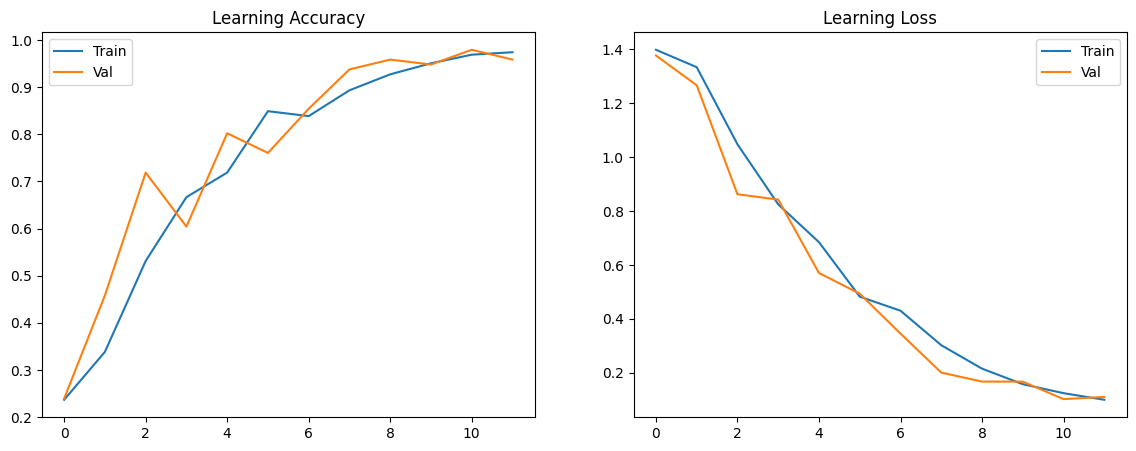

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


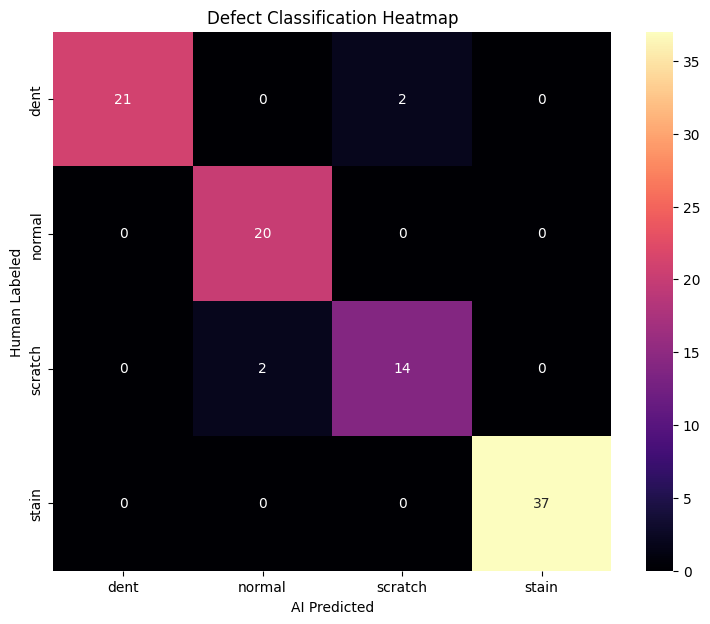

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        dent       1.00      0.91      0.95        23
      normal       0.91      1.00      0.95        20
     scratch       0.88      0.88      0.88        16
       stain       1.00      1.00      1.00        37

    accuracy                           0.96        96
   macro avg       0.95      0.95      0.95        96
weighted avg       0.96      0.96      0.96        96



In [4]:
# 1. Training Cycle
print("⚡ Training model...")
run_history = model.fit(train_stream, validation_data=val_stream, epochs=12, verbose=1)

# 2. Metric Visualization
def plot_performance(hist):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(hist.history['accuracy'], label='Train'); ax[0].plot(hist.history['val_accuracy'], label='Val')
    ax[0].set_title('Learning Accuracy'); ax[0].legend()
    ax[1].plot(hist.history['loss'], label='Train'); ax[1].plot(hist.history['val_loss'], label='Val')
    ax[1].set_title('Learning Loss'); ax[1].legend()
    plt.savefig('results/accuracy_loss_curves.png')
    plt.show()

plot_performance(run_history)

# 3. Final Multi-Class Evaluation
val_stream.reset()
raw_preds = model.predict(val_stream)
y_pred = np.argmax(raw_preds, axis=1)
y_true = val_stream.classes

# Confusion Matrix Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='magma',
            xticklabels=val_stream.class_indices.keys(), 
            yticklabels=val_stream.class_indices.keys())
plt.title('Defect Classification Heatmap')
plt.xlabel('AI Predicted'); plt.ylabel('Human Labeled')
plt.savefig('results/confusion_matrix.png')
plt.show()

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=val_stream.class_indices.keys()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


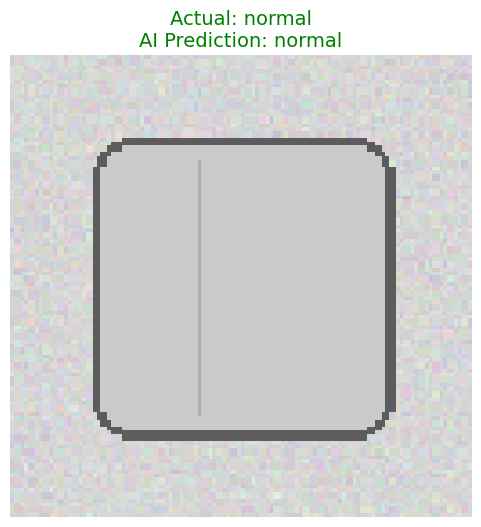

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab a small batch of images from the validation stream
x_samples, y_samples = next(val_stream)

# 2. Get the prediction for the first image in that batch
preds = model.predict(x_samples)

# 3. Decode the labels (from numbers back to names like 'dent' or 'stain')
class_names = list(val_stream.class_indices.keys())
actual_name = class_names[np.argmax(y_samples[0])]
predicted_name = class_names[np.argmax(preds[0])]

# 4. Create the visual output
plt.figure(figsize=(6, 6))
plt.imshow(x_samples[0])
plt.title(f"Actual: {actual_name}\nAI Prediction: {predicted_name}", 
          fontsize=14, color='green' if actual_name == predicted_name else 'red')
plt.axis('off')

# 5. SAVE TO YOUR FOLDER
plt.savefig('sample_predictions/prediction_outputs.png', bbox_inches='tight')
plt.show()

